In [234]:
# Estas lineas evitan la necesidad de reiniciar manualmente el kernel o recargar módulos importados cada vez que realizas un cambio en el código
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [235]:
import random
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [236]:
from src.utils import print_dataset_extract
from src.preprocessing import fix_data, gestionar_valores_faltantes

# Analisis exploratorio y preprocesamiento

## 1.1

In [237]:
df_dev = pd.read_csv('data/raw/rendimiento_estudiantes_dev.csv')
df_test = pd.read_csv('data/raw/rendimiento_estudiantes_test.csv')

In [238]:
#un poquito de preprocessing

dict_performance_bin = {"Excelente": 1, "Bueno": 1, "Regular": 1, "Insuficiente": 0}
dict_performance_mult = {"Excelente": 3, "Bueno": 2, "Regular": 1, "Insuficiente": 0}
df_dev["rendimiento_bin"] = df_dev["rendimiento"].map(dict_performance_bin)
df_dev["rendimiento_mult"] = df_dev["rendimiento"].map(dict_performance_mult)

df_dev["escuela"] = df_dev["escuela"].str.upper()

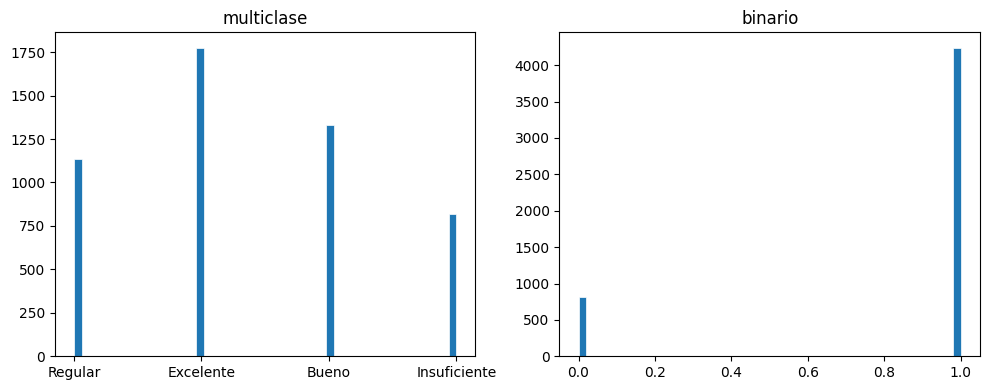

In [239]:
def graficar_targets(lista1, lista2, titulo1, titulo2):
    fig, axs = plt.subplots(1, 2, figsize=(10, 4))
    axs[0].hist(lista1, bins=50, linewidth=0.5, edgecolor="white")
    axs[0].set_title(titulo1)
    axs[1].hist(lista2, bins=50, linewidth=0.5, edgecolor="white")
    axs[1].set_title(titulo2)
    plt.tight_layout()
    plt.show()

def graficar(df, features_list):
    rows = len(features_list) // 3 #divido por 3 porque quiero 3 columnas
    fig, axs = plt.subplots(rows, 3, figsize=(3 * 4, rows * 3))
    axs = axs.flatten()

    for i, feature in enumerate(features_list):
        axs[i].hist(df[feature].dropna(), bins=30, edgecolor="white", linewidth=0.5)
        axs[i].set_title(feature)

    plt.tight_layout()
    plt.show()


graficar_targets(df_dev["rendimiento"], df_dev["rendimiento_bin"], "multiclase", "binario")
features_graficar = ["horas_estudio", "asistencia", "nota_previa", "horas_sueno", "participacion", 
                    "horas_extracurricular", "acceso_internet", "distancia_escuela_km", 
                     "nivel_socioeconomico", "tamano_clase", "escuela", "semestre"]
#graficar(df_dev, features_graficar)


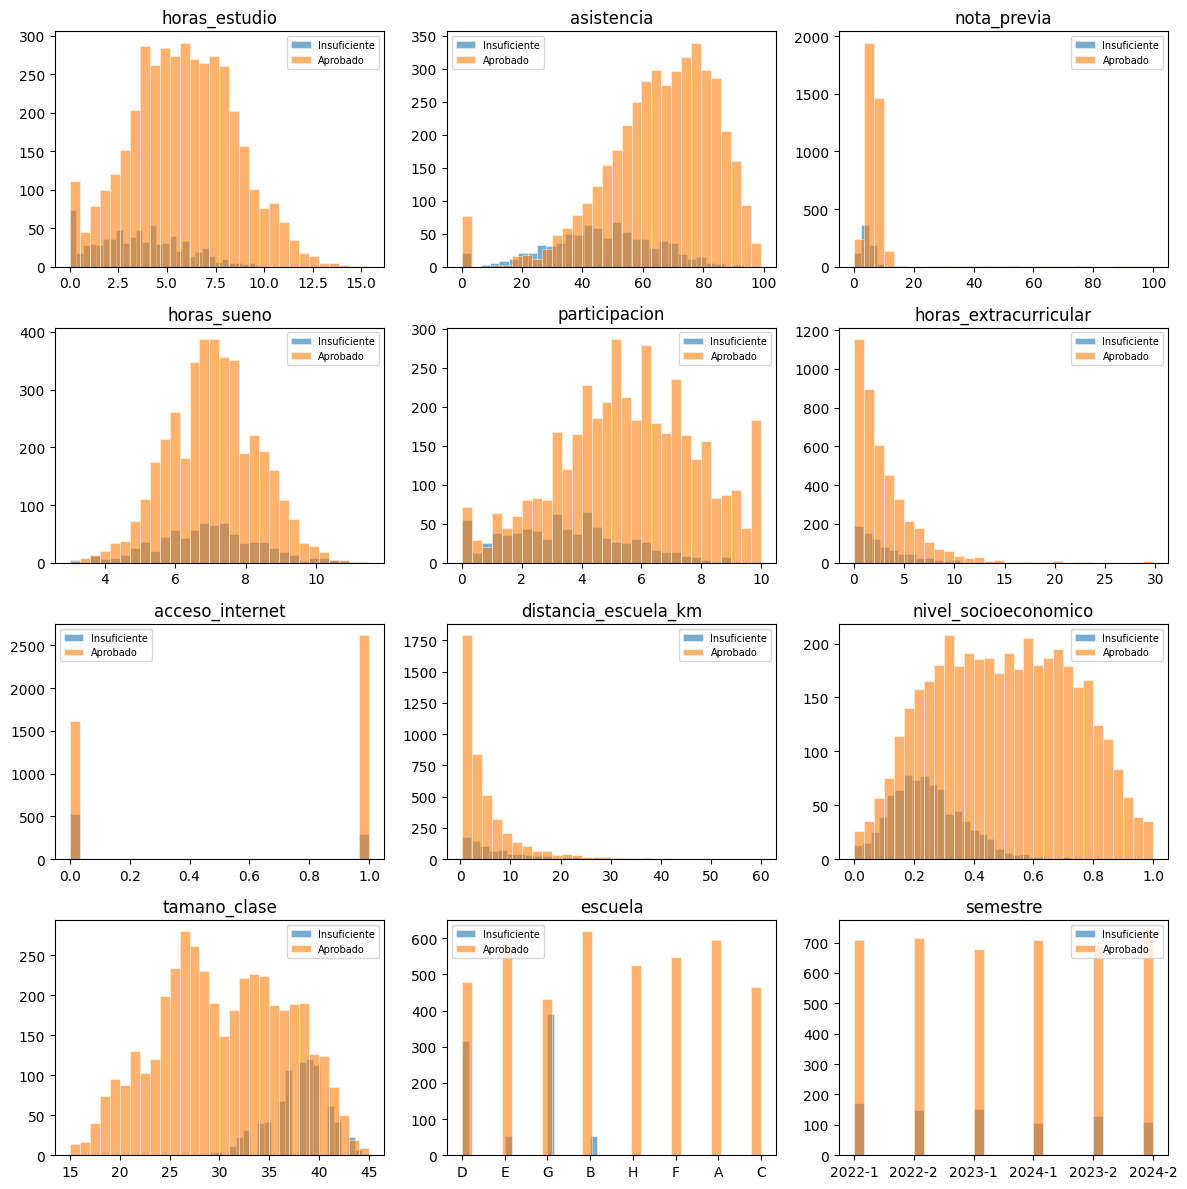

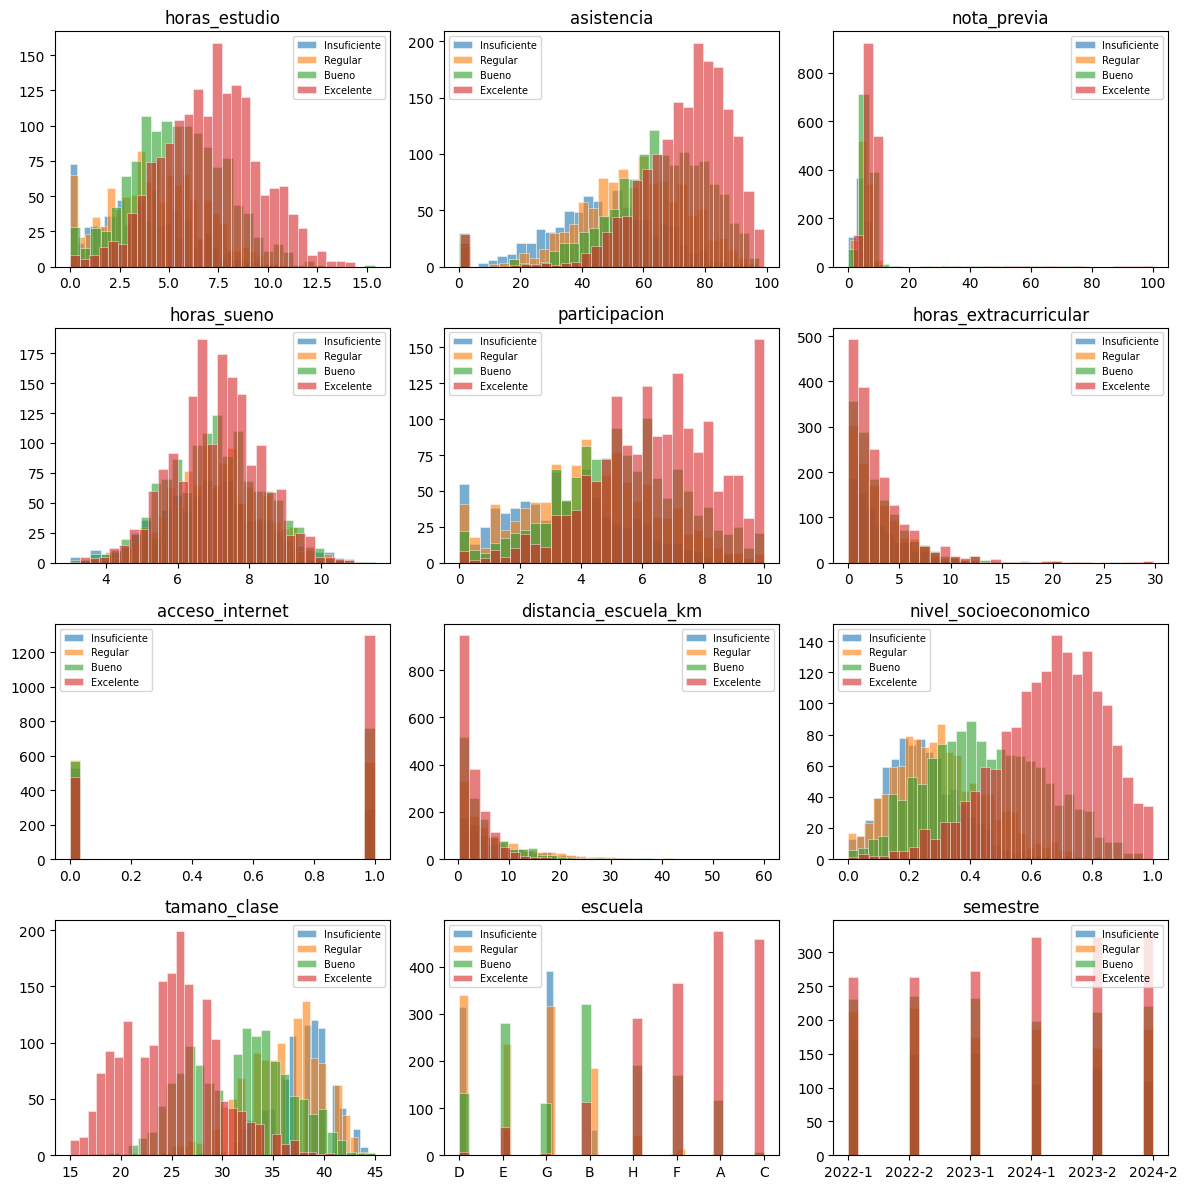

In [240]:
#chatgpt: 
def graficar_por_clase(df, features_list, target="rendimiento_bin"):
    rows = len(features_list) // 3
    fig, axs = plt.subplots(rows, 3, figsize=(3 * 4, rows * 3))
    axs = axs.flatten()

    clases = df[target].dropna().unique()
    if target == "rendimiento_bin":
        labels  = {0: "Insuficiente", 1: "Aprobado"}
    elif target == "rendimiento_mult":
        labels = {0: "Insuficiente", 1: "Regular", 2: "Bueno", 3: "Excelente"}
    elif target == "escuela":
        labels = {c:str(c) for c in clases}

    for i, feature in enumerate(features_list):
        for clase in sorted(clases):
            datos = df.loc[df[target] == clase, feature].dropna()
            axs[i].hist(datos, bins=30, alpha=0.6, edgecolor="white",
                        linewidth=0.5, label=labels.get(clase, clase))
        axs[i].set_title(feature)
        axs[i].legend(fontsize=7)

    plt.tight_layout()
    plt.show()
    
graficar_por_clase(df_dev, features_graficar, "rendimiento_bin")
graficar_por_clase(df_dev, features_graficar, "rendimiento_mult")
#graficar_por_clase(df_dev, features_graficar, "escuela") #no era demasiado claro

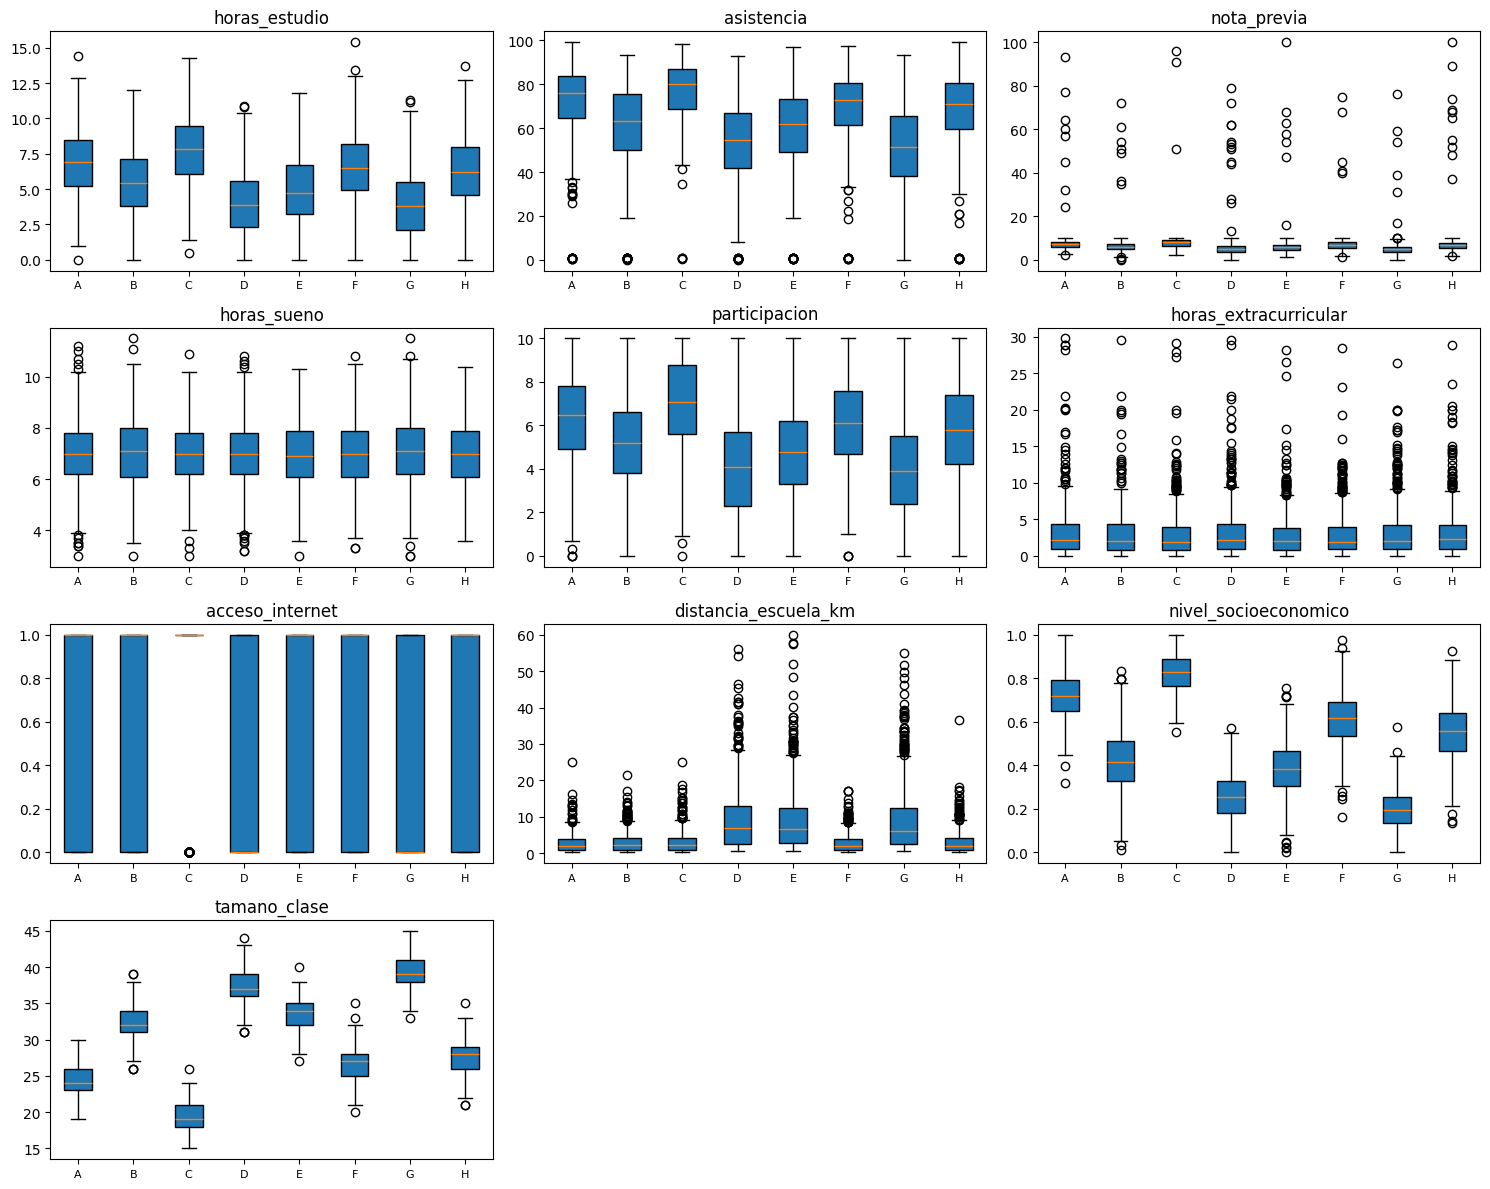

In [241]:
import math 
#chatgpt: 
def graficar_por_escuela(df, features_list):
    cols = 3
    rows = math.ceil(len(features_list) / cols)    
    fig, axs = plt.subplots(rows, cols, figsize=(cols * 5, rows * 3))
    axs = axs.flatten()

    escuelas = sorted(df["escuela"].dropna().unique())

    for i, feature in enumerate(features_list):
        data_by_escuela = [df.loc[df["escuela"] == e, feature].dropna() for e in escuelas]
        axs[i].boxplot(data_by_escuela, tick_labels=escuelas, patch_artist=True)
        axs[i].set_title(feature)
        axs[i].tick_params(axis="x", labelsize=8)

    for j in range(i + 1, len(axs)):
        axs[j].set_visible(False)

    plt.tight_layout()
    plt.show()

features_graficar = ["horas_estudio", "asistencia", "nota_previa", "horas_sueno", "participacion", 
                    "horas_extracurricular", "acceso_internet", "distancia_escuela_km",
                     "nivel_socioeconomico", "tamano_clase"] #TODO: agregar semestre?

graficar_por_escuela(df_dev, features_graficar)

In [244]:
print_dataset_extract(df_dev)

      horas_estudio  asistencia  nota_previa  horas_sueno  participacion  \
2203            5.5        34.6          NaN          4.4            2.4   
2204            9.7        48.3          6.8          6.0            6.3   
2205            8.3        53.6          6.8          4.6            0.7   
2206            8.8        84.5          6.5          7.4            7.5   
2207            8.7        82.5          NaN          7.6            8.2   
2208            2.1        61.1          7.4          7.3            5.8   
2209            6.2        75.2          NaN          6.1            4.7   

      horas_extracurricular  acceso_internet  distancia_escuela_km  \
2203              21.951994                1                   8.9   
2204               0.700000                0                   1.9   
2205               3.100000                0                  26.4   
2206               0.900000                0                   1.1   
2207               6.600000              

In [245]:
df_dev.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5058 entries, 0 to 5057
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   horas_estudio          4783 non-null   float64
 1   asistencia             5058 non-null   float64
 2   nota_previa            4530 non-null   float64
 3   horas_sueno            4785 non-null   float64
 4   participacion          4878 non-null   float64
 5   horas_extracurricular  5058 non-null   float64
 6   acceso_internet        5058 non-null   int64  
 7   distancia_escuela_km   5058 non-null   float64
 8   nivel_socioeconomico   4966 non-null   float64
 9   tamano_clase           5058 non-null   int64  
 10  escuela                5058 non-null   object 
 11  semestre               5058 non-null   object 
 12  rendimiento            5058 non-null   object 
 13  rendimiento_bin        5058 non-null   int64  
 14  rendimiento_mult       5058 non-null   int64  
dtypes: f

In [246]:
print(df_dev["rendimiento"].value_counts())
print()
print(df_dev["escuela"].value_counts())
print()
print(df_dev["semestre"].value_counts())

rendimiento
Excelente       1775
Bueno           1329
Regular         1136
Insuficiente     818
Name: count, dtype: int64

escuela
G    821
D    793
B    673
E    631
A    596
F    551
H    529
C    464
Name: count, dtype: int64

semestre
2022-1    879
2022-2    866
2024-2    847
2023-1    831
2023-2    820
2024-1    815
Name: count, dtype: int64


Observing some stats from the dataset, it is visible that some features are categorical, such as "rendimiento", "escuela" and "semestre". <br> For the first one, there are four types: Excelente, Bueno, Regular and Insuficiente. For multiclass classification I choose to represent those categories with 3, 2, 1, 0 respectivelly (there is a clear order, we suppose the distance between the labels is the same). Instead, for binary classification we must group Excelente, Bueno and Regular in "Pass" (1), opposed to Insuficiente, "Fail" (0). <br> We can see in "escuela" there are 8 different options: from a to h, I choose to do One hot encoding (we must convert the upper cases in lower cases before). <br> For "semestre" there is a progression, an order, There are 6 options so, in chronological order I assign an index to each time period: 2022-1 is 1, 2022-2 is 2, 2023-1 is 3, etc...

In [247]:
print(df_dev.isna().mean())

horas_estudio            0.054369
asistencia               0.000000
nota_previa              0.104389
horas_sueno              0.053974
participacion            0.035587
horas_extracurricular    0.000000
acceso_internet          0.000000
distancia_escuela_km     0.000000
nivel_socioeconomico     0.018189
tamano_clase             0.000000
escuela                  0.000000
semestre                 0.000000
rendimiento              0.000000
rendimiento_bin          0.000000
rendimiento_mult         0.000000
dtype: float64


In [248]:
df_dev = fix_data(df_dev)
df_test = fix_data(df_test)

df_dev = gestionar_valores_faltantes(df_dev) #TODO: mejorar esto,no eliminar a lo loco
print_dataset_extract(df_dev)

      A  B  C  D  E  F  G  horas_estudio  asistencia  nota_previa  \
2718  0  0  1  0  0  0  0            4.4        89.3          5.4   
2719  0  0  0  0  1  0  0            1.8        55.4          5.6   
2720  0  0  0  0  1  0  0            6.7        39.1          5.6   
2722  0  0  0  0  0  0  1            5.7        44.6          4.0   
2723  0  0  0  1  0  0  0            8.0        42.3          2.0   
2725  1  0  0  0  0  0  0            3.1        74.8          6.8   
2726  0  0  0  0  1  0  0            3.3        53.7          5.5   

      horas_sueno  participacion  horas_extracurricular  acceso_internet  \
2718          6.4            6.9                    0.4                1   
2719          5.0            2.0                    3.8                0   
2720          7.3            7.9                    1.0                1   
2722          7.9            4.6                    1.7                0   
2723          6.3            6.6                    0.3            